# Tâche 2 : Analyse d'un sous-échantillon selon l'âge

## Contexte

La tâche 1 a montré que certains sites généralisent mal (OHSU, CALTECH, MAX_MUN). On peut alors se demander si ce n'est pas a cause d'un effet d'age

## Objectif

Cette tâche se déroule en deux temps :

1. **Description complète du dataset ABIDE** : examiner les caractéristiques des participants (âge, score ADOS, ratio ASD/TD par site) pour comprendre la composition du dataset.
2. **Sélection et analyse d'un sous-échantillon** : à partir de l'exploration des données, choisir une limite d'âge justifiée, décrire le sous-échantillon obtenu, puis reproduire le pipeline de classification de la tâche 1 sur ce sous-groupe.

**Question scientifique** : est-ce que les performances de classification et les effets de site sont différents selon le groupe d'âge ?

## Instructions de reproduction

Ce notebook suppose que les données ABIDE ont déjà été préparées. Voici les étapes :

```bash
# 1. Cloner le dépôt
git clone https://github.com/psy3019-6973-2026/Francois_Presentation_Projet_ABIDE-fMRI.git
cd Francois_Presentation_Projet_ABIDE-fMRI

# 2. Créer et activer l'environnement
conda env create -f environment.yml
conda activate env_abide

# 3. Préparer les données (~8h)
make prepare

# 4. Lancer ce notebook
cd notebook
jupyter notebook
```

Ce notebook utilise des **chemins relatifs** (`data/` et `output/`) afin d'être reproductible sur n'importe quelle machine.

## 1. Imports

In [4]:
import warnings
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from nilearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

## 2. Chargement des données

In [6]:
#project_root = Path.cwd().parent
#data_path = project_root / "output" / "ABIDE_BASC064_features.npz"
#data_dir  = project_root / "data"


# Fonctionne avec jupyter notebook ET make nbconvert
project_root = Path(os.getcwd())
if project_root.name == "notebook":
    project_root = project_root.parent
    
assert data_path.exists(), f"Fichier introuvable : {data_path}. Avez-vous exécuté prepare_data.py ?"

# Features
data = np.load(data_path, allow_pickle=True)
X = data["a"]

# Phénotype
abide = datasets.fetch_abide_pcp(
    data_dir=str(data_dir),
    pipeline="cpac",
    quality_checked=True
)
pheno = pd.DataFrame(abide.phenotypic)

# Variables utiles
y    = (pheno["DX_GROUP"] == 1).astype(int).to_numpy()  # 1=ASD, 0=TD
site = pheno["SITE_ID"].to_numpy()

# Colonne diagnostic lisible
pheno["DX"] = pheno["DX_GROUP"].map({1: "ASD", 2: "TD"})

assert X.shape[0] == len(y) == len(site), "Désalignement entre X, y et site !"
print(f"Total participants : {len(y)}")
print(f"ASD : {y.sum()}  |  TD : {(y==0).sum()}")
print(f"Nombre de sites : {len(np.unique(site))}")

[fetch_abide_pcp] Dataset found in /mnt/d/udem/PSY3019/Francois_Presentation_Projet_ABIDE-fMRI/data/ABIDE_pcp
Total participants : 871
ASD : 403  |  TD : 468
Nombre de sites : 20


---
# PARTIE 1 : Description complète du dataset ABIDE

## 3. Distribution de l'âge

In [7]:
# Statistiques descriptives de l'âge par groupe
print("=== Statistiques d'âge par groupe ===")
print(pheno.groupby("DX")["AGE_AT_SCAN"].describe().round(2))

=== Statistiques d'âge par groupe ===
     count   mean   std   min    25%    50%    75%   max
DX                                                      
ASD  403.0  17.07  7.96  7.00  11.78  14.65  19.12  58.0
TD   468.0  16.84  7.24  6.47  12.03  14.80  20.00  56.2


### Interprétation :
Les groupes ASD et TD sont bien appariés en âge (médiane ~14.7 ans pour les deux). 
Cependant la grande étendue (7 à 58 ans) montre une forte hétérogénéité 

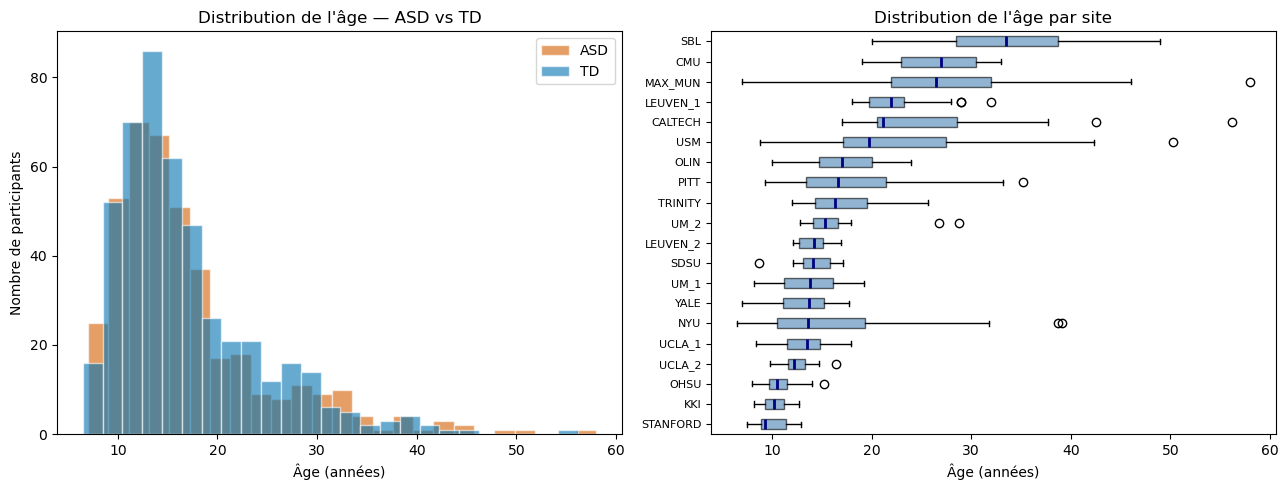

Figure sauvegardée : age_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panneau gauche : histogramme superposé ASD vs TD ---
for group, color in [("ASD", "#D55E00"), ("TD", "#0072B2")]: # Couleurs daltonien-friendly
    subset = pheno[pheno["DX"] == group]["AGE_AT_SCAN"].dropna()
    axes[0].hist(subset, bins=25, alpha=0.6, color=color, label=group, edgecolor="white")

axes[0].set_xlabel("Âge (années)")
axes[0].set_ylabel("Nombre de participants")
axes[0].set_title("Distribution de l'âge — ASD vs TD")
axes[0].legend()

# --- Panneau droit : boxplot par site ---
site_order = pheno.groupby("SITE_ID")["AGE_AT_SCAN"].median().sort_values().index
data_by_site = [pheno[pheno["SITE_ID"] == s]["AGE_AT_SCAN"].dropna().values for s in site_order]

bp = axes[1].boxplot(data_by_site, vert=False, patch_artist=True,
                     boxprops=dict(facecolor="steelblue", alpha=0.6),
                     medianprops=dict(color="navy", linewidth=2))
axes[1].set_yticks(range(1, len(site_order) + 1))
axes[1].set_yticklabels(site_order, fontsize=8)
axes[1].set_xlabel("Âge (années)")
axes[1].set_title("Distribution de l'âge par site")

plt.tight_layout()
plt.savefig("../output/age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : age_distribution.png")

### Interprétation :
Le panneau gauche montre que la majorité des participants ont entre 8 et 20 ans. La distribution est asymétrique avec une  longue queue vers les adultes.

Le panneau droit montre que l'âge varie beaucoup selon les sites :
- STANFORD et KKI : participants très jeunes (médiane d'environ 10 ans)
- SBL  participants plus âgés (médiane d'environ 30 ans)

Cette variabilité d'âge inter-site peut contribuer aux effets de site observés en tâche 1 

## 4. Distribution du score ADOS_TOTAL (participants ASD uniquement)

In [11]:
asd_pheno = pheno[pheno["DX"] == "ASD"].copy()

# Remplacer les valeurs manquantes ou aberrantes (-9999 est souvent utilisé dans ABIDE)
asd_pheno["ADOS_TOTAL"] = asd_pheno["ADOS_TOTAL"].replace(-9999, np.nan)
asd_pheno["ADOS_TOTAL"] = pd.to_numeric(asd_pheno["ADOS_TOTAL"], errors="coerce")

print(f"Participants ASD avec ADOS_TOTAL disponible : {asd_pheno['ADOS_TOTAL'].notna().sum()} / {len(asd_pheno)}")
print("\n=== Statistiques ADOS_TOTAL ===")
print(asd_pheno["ADOS_TOTAL"].describe().round(2))

Participants ASD avec ADOS_TOTAL disponible : 282 / 403

=== Statistiques ADOS_TOTAL ===
count    282.00
mean      11.75
std        3.74
min        2.00
25%        9.00
50%       12.00
75%       14.00
max       22.00
Name: ADOS_TOTAL, dtype: float64


### Interprétation :

282 participants ASD sur 403 ont un score ADOS disponible (30% de données manquantes).

Le score médian est 12, ce qui correspond à une sévérité modérée. 
L'étendue (2 à 22) montre que le dataset inclut des profils très variés dans le spectre de l'autisme

**Attention** Cette variabilité de sévérité peut rendre la classification plus difficile (ex. un participant ASD avec un score de 2 ressemble probablement plus à un TD qu'un participant avec un score de 22)

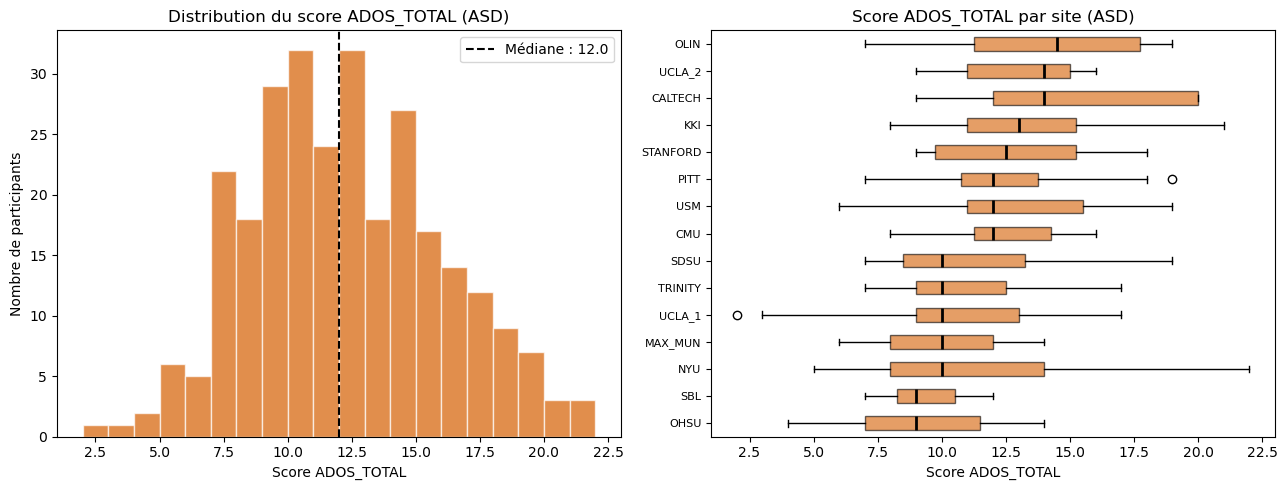

Figure sauvegardée : ados_distribution.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panneau gauche
axes[0].hist(ados_valid, bins=20, color="#D55E00", alpha=0.7, edgecolor="white")
axes[0].axvline(ados_valid.median(), color="black", linestyle="--",
                linewidth=1.5, label=f"Médiane : {ados_valid.median():.1f}")
axes[0].set_xlabel("Score ADOS_TOTAL")
axes[0].set_ylabel("Nombre de participants")
axes[0].set_title("Distribution du score ADOS_TOTAL (ASD)")
axes[0].legend()

# Panneau droit : boxplot ADOS_TOTAL par site
site_ados = asd_pheno.groupby("SITE_ID")["ADOS_TOTAL"].median().sort_values().dropna()
data_ados_by_site = [
    asd_pheno[asd_pheno["SITE_ID"] == s]["ADOS_TOTAL"].dropna().values
    for s in site_ados.index
]
# Garder seulement les sites avec au moins 2 valeurs
valid = [(s, d) for s, d in zip(site_ados.index, data_ados_by_site) if len(d) >= 2]
site_labels, data_ados_valid = zip(*valid)

axes[1].boxplot(data_ados_valid, vert=False, patch_artist=True,
                boxprops=dict(facecolor="#D55E00", alpha=0.6),
                medianprops=dict(color="black", linewidth=2))
axes[1].set_yticks(range(1, len(site_labels) + 1))
axes[1].set_yticklabels(site_labels, fontsize=8)
axes[1].set_xlabel("Score ADOS_TOTAL")
axes[1].set_title("Score ADOS_TOTAL par site (ASD)")

plt.tight_layout()
plt.savefig("../output/ados_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : ados_distribution.png")

### Interprétation :
Le panneau gauche montre que les scores ADOS sont concentrés entre 8 et 16 ans

Le panneau droit montre que les profils autistiques varient selon les sites :
- OLIN, UCLA_2, CALTECH → scores plus élevés 
- OHSU, SBL → scores plus bas 

Cette variabilité inter-site des profils autistiques pourrait contribuer aux effets de site observés en tâche 1. 
OHSU par exemple a des participants ASD avec des scores ADOS plus bas, ce qui signifie que leurs profils de connectivité ressemblent 
davantage à ceux des TD, rendant la classification plus difficile.

## 5. Composition par site (ratio ASD/TD)

In [19]:
# Tableau récapitulatif par site
site_summary = pheno.groupby("SITE_ID").apply(
    lambda g: pd.Series({
        "n_total":     len(g),
        "n_ASD":       (g["DX"] == "ASD").sum(),
        "n_TD":        (g["DX"] == "TD").sum(),
        "ratio_ASD":   (g["DX"] == "ASD").mean().round(2),
        "age_median":  g["AGE_AT_SCAN"].median().round(1),
        "age_min":     g["AGE_AT_SCAN"].min().round(1),
        "age_max":     g["AGE_AT_SCAN"].max().round(1),
    }), include_groups=False
).sort_values("n_total", ascending=False)


print("=== Récapitulatif par site ===")
print(site_summary.to_string())

=== Récapitulatif par site ===
          n_total  n_ASD  n_TD  ratio_ASD  age_median  age_min  age_max
SITE_ID                                                                
NYU         172.0   74.0  98.0       0.43        13.7      6.5     39.1
UM_1         86.0   34.0  52.0       0.40        13.8      8.2     19.2
USM          67.0   43.0  24.0       0.64        19.8      8.8     50.2
UCLA_1       64.0   37.0  27.0       0.58        13.5      8.4     17.9
PITT         50.0   24.0  26.0       0.48        16.6      9.3     35.2
MAX_MUN      46.0   19.0  27.0       0.41        26.5      7.0     58.0
TRINITY      44.0   19.0  25.0       0.43        16.4     12.0     25.7
YALE         41.0   22.0  19.0       0.54        13.8      7.0     17.8
UM_2         34.0   13.0  21.0       0.38        15.3     12.8     28.8
KKI          33.0   12.0  21.0       0.36        10.2      8.2     12.8
LEUVEN_1     28.0   14.0  14.0       0.50        22.0     18.0     32.0
LEUVEN_2     28.0   12.0  16.0   

### Interprétation :
Le tableau montre une grande hétérogénéité d'âge entre les sites :
- Certains sites recrutent exclusivement des enfants (STANFORD, KKI, OHSU ou age_max < 16 ans)
- D'autres recrutent que des adultes (LEUVEN_1 age_min=18 ans, SBL age_min=20 ans)


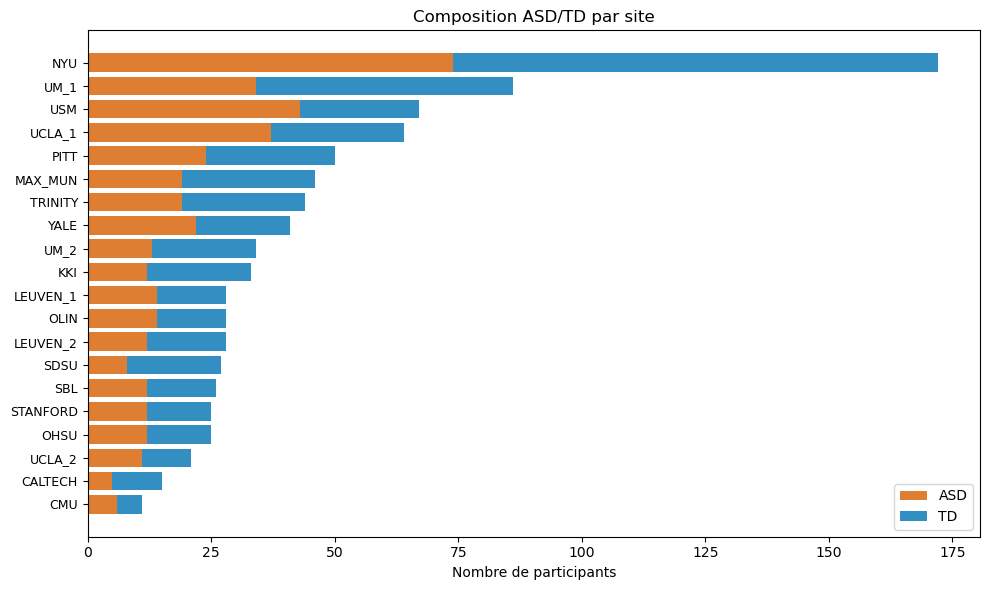

Figure sauvegardée : composition_par_site.png


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

site_sorted = site_summary.sort_values("n_total", ascending=True)
x = np.arange(len(site_sorted))

# couleur eco daltonien
ax.barh(x, site_sorted["n_ASD"], color="#D55E00", alpha=0.8, label="ASD")
ax.barh(x, site_sorted["n_TD"],  left=site_sorted["n_ASD"],
        color="#0072B2", alpha=0.8, label="TD")

ax.set_yticks(x)
ax.set_yticklabels(site_sorted.index, fontsize=9)
ax.set_xlabel("Nombre de participants")
ax.set_title("Composition ASD/TD par site")
ax.legend()

plt.tight_layout()
plt.savefig("../output/composition_par_site.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : composition_par_site.png")

### Interprétation :
NYU domine largement le dataset avec 172 participants presque le double du deuxième site (UM_1)

On remarque aussi que certains sites ont un déséquilibre 
ASD/TD notable :
- USM :  plus d'ASD que de TD
- SDSU :  plus de TD que d'ASD

Ce déséquilibre peut affecter les performances du modèle sur ces sites spécifiques.

---
# PARTIE 2 : Sélection et analyse du sous-échantillon

## 6. Choix de la limite d'âge

À compléter après avoir observé les figures ci-dessus.

**Justification du seuil choisi :** 
 Seuil choisi à 18 ans 

L'histogramme de la section 3 montre une distribution bimodale avec un pic
majoritaire entre 7 et 18 ans, suivi d'une queue étalée jusqu'à ~58 ans.

La médiane est de 14.65 ans (ASD) et 14.80 ans (TD), confirmant que

la majorité des participants sont des enfants ou adolescents.

Le seuil de 18 ans correspond à la frontière naturelle entre l'adolescence
et l'âge adulte. Sur le plan neurobiologique, les manifestations du TSA
évoluent significativement avec le développement : les symptômes observés
chez l'enfant/adolescent diffèrent de ceux de l'adulte, ce qui peut
introduire une hétérogénéité dans les features de connectivité fonctionnelle.

En se restreignant aux participants de moins de 18 ans, on réduit cette
source de variabilité tout en conservant la majorité de l'échantillon.


In [9]:
AGE_MAX = 18 

sub_mask = pheno["AGE_AT_SCAN"] <= AGE_MAX

X_sub    = X[sub_mask]
y_sub    = y[sub_mask]
site_sub = site[sub_mask]
pheno_sub = pheno[sub_mask].copy()

assert X_sub.shape[0] == len(y_sub) == len(site_sub)
print(f"Seuil d'âge : <= {AGE_MAX} ans")
print(f"Participants sélectionnés : {len(y_sub)} / {len(y)}")
print(f"ASD : {y_sub.sum()}  |  TD : {(y_sub==0).sum()}")
print(f"Sites représentés : {len(np.unique(site_sub))}")

Seuil d'âge : <= 18 ans
Participants sélectionnés : 613 / 871
ASD : 286  |  TD : 327
Sites représentés : 18


## 7. Description du sous-échantillon sélectionné

In [10]:
print("=== Statistiques d'âge par groupe — sous-échantillon ===")
print(pheno_sub.groupby("DX")["AGE_AT_SCAN"].describe().round(2))

asd_sub = pheno_sub[pheno_sub["DX"] == "ASD"].copy()
asd_sub["ADOS_TOTAL"] = asd_sub["ADOS_TOTAL"].replace(-9999, np.nan)
asd_sub["ADOS_TOTAL"] = pd.to_numeric(asd_sub["ADOS_TOTAL"], errors="coerce")

print("\n=== Statistiques ADOS_TOTAL — sous-échantillon ASD ===")
print(asd_sub["ADOS_TOTAL"].describe().round(2))

=== Statistiques d'âge par groupe — sous-échantillon ===
     count   mean   std   min    25%    50%    75%   max
DX                                                      
ASD  286.0  13.03  2.80  7.00  10.93  13.04  15.12  18.0
TD   327.0  12.99  2.74  6.47  10.82  13.25  15.01  18.0

=== Statistiques ADOS_TOTAL — sous-échantillon ASD ===
count    201.00
mean      11.65
std        3.84
min        2.00
25%        9.00
50%       11.00
75%       14.00
max       22.00
Name: ADOS_TOTAL, dtype: float64


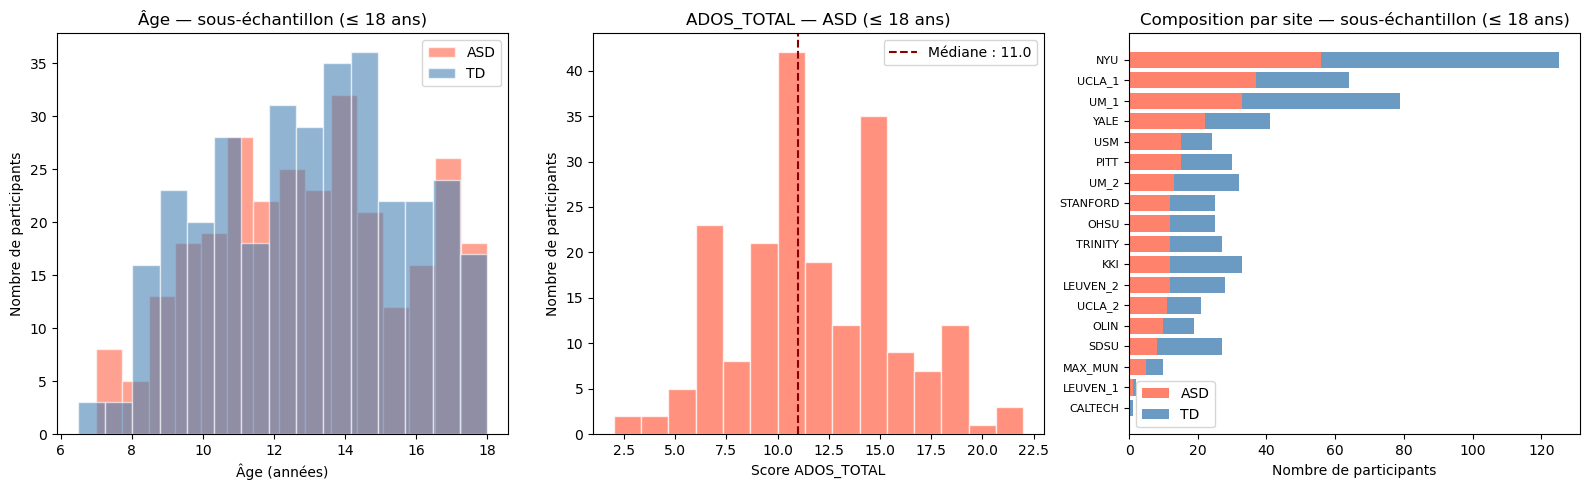

Figure sauvegardée : description_sous_echantillon.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Distribution âge sous-échantillon ---
for group, color in [("ASD", "tomato"), ("TD", "steelblue")]:
    subset = pheno_sub[pheno_sub["DX"] == group]["AGE_AT_SCAN"].dropna()
    axes[0].hist(subset, bins=15, alpha=0.6, color=color, label=group, edgecolor="white")
axes[0].set_xlabel("Âge (années)")
axes[0].set_ylabel("Nombre de participants")
axes[0].set_title(f"Âge — sous-échantillon (≤ {AGE_MAX} ans)")
axes[0].legend()

# --- Distribution ADOS sous-échantillon ---
ados_sub_valid = asd_sub["ADOS_TOTAL"].dropna()
if len(ados_sub_valid) > 0:
    axes[1].hist(ados_sub_valid, bins=15, color="tomato", alpha=0.7, edgecolor="white")
    axes[1].axvline(ados_sub_valid.median(), color="darkred", linestyle="--",
                    linewidth=1.5, label=f"Médiane : {ados_sub_valid.median():.1f}")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Pas de données ADOS", ha="center", va="center",
                 transform=axes[1].transAxes)
axes[1].set_xlabel("Score ADOS_TOTAL")
axes[1].set_ylabel("Nombre de participants")
axes[1].set_title(f"ADOS_TOTAL — ASD (≤ {AGE_MAX} ans)")

# --- Composition ASD/TD par site dans le sous-échantillon ---
site_sub_summary = pheno_sub.groupby("SITE_ID").apply(
    lambda g: pd.Series({"n_ASD": (g["DX"]=="ASD").sum(), "n_TD": (g["DX"]=="TD").sum()}),
    include_groups=False
).sort_values("n_ASD", ascending=True)



x = np.arange(len(site_sub_summary))
axes[2].barh(x, site_sub_summary["n_ASD"], color="tomato", alpha=0.8, label="ASD")
axes[2].barh(x, site_sub_summary["n_TD"], left=site_sub_summary["n_ASD"],
             color="steelblue", alpha=0.8, label="TD")
axes[2].set_yticks(x)
axes[2].set_yticklabels(site_sub_summary.index, fontsize=8)
axes[2].set_xlabel("Nombre de participants")
axes[2].set_title(f"Composition par site — sous-échantillon (≤ {AGE_MAX} ans)")
axes[2].legend()

plt.tight_layout()
plt.savefig("description_sous_echantillon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : description_sous_echantillon.png")

## 8. Pipeline de classification sur le sous-échantillon

On reproduit exactement le même pipeline que la tâche 1 (régression logistique + StandardScaler), avec les deux mêmes stratégies de validation croisée, appliquées cette fois uniquement sur le sous-échantillon sélectionné.

In [12]:
base_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, random_state=42))
])


def kfold_within_site(X, y, site, n_splits=5, random_state=42):
    """Même fonction que tâche 1 — 5-fold stratifié par site."""
    site_fold_indices = {s: [] for s in np.unique(site)}

    for s in np.unique(site):
        idx_s = np.where(site == s)[0]
        y_s   = y[idx_s]

        if len(np.unique(y_s)) < 2:
            warnings.warn(f"Site '{s}' n'a qu'une seule classe, ignoré.", UserWarning)
            continue

        min_class_count = np.bincount(y_s).min()

        if min_class_count < 2:
            warnings.warn(
                f"Site '{s}' : classe minoritaire = {min_class_count} sujet, "
                f"impossible de faire un split. Site ignoré.", UserWarning
            )
            continue

        effective_splits = min(n_splits, min_class_count)
        if effective_splits < n_splits:
            warnings.warn(
                f"Site '{s}' : classe minoritaire = {min_class_count} sujets, "
                f"n_splits réduit à {effective_splits}.", UserWarning
            )

        skf = StratifiedKFold(n_splits=effective_splits, shuffle=True, random_state=random_state)
        site_fold_indices[s] = [(idx_s[tr], idx_s[te]) for tr, te in skf.split(idx_s, y_s)]

    valid_sites = [s for s in site_fold_indices if len(site_fold_indices[s]) > 0]
    folds = []
    for fold_i in range(n_splits):
        train_all, test_all = [], []
        for s in valid_sites:
            folds_s = site_fold_indices[s]
            fi = fold_i % len(folds_s)
            train_all.extend(folds_s[fi][0])
            test_all.extend(folds_s[fi][1])
        folds.append((np.array(train_all), np.array(test_all)))
    return folds


def evaluate_cv(folds, X, y, base_model):
    """Évalue le modèle sur une liste de folds."""
    results = []
    for fold_i, (train_idx, test_idx) in enumerate(folds):
        model = clone(base_model)
        model.fit(X[train_idx], y[train_idx])
        y_pred  = model.predict(X[test_idx])
        y_score = model.predict_proba(X[test_idx])[:, 1]

        if len(np.unique(y[test_idx])) < 2:
            warnings.warn(f"Fold {fold_i} : une seule classe dans le test, ROC-AUC = NaN.", UserWarning)
            auc = np.nan
        else:
            auc = roc_auc_score(y[test_idx], y_score)

        results.append({
            "fold":              fold_i,
            "accuracy":          accuracy_score(y[test_idx], y_pred),
            "balanced_accuracy": balanced_accuracy_score(y[test_idx], y_pred),
            "roc_auc":           auc,
        })
    return pd.DataFrame(results)

In [13]:
# --- Intra-site ---
folds_intra_sub = kfold_within_site(X_sub, y_sub, site_sub, n_splits=5)
results_intra_sub = evaluate_cv(folds_intra_sub, X_sub, y_sub, base_model)

print("=== Intra-site — sous-échantillon ===")
print(results_intra_sub.round(3).to_string(index=False))
print("\nMoyenne :")
print(results_intra_sub[["accuracy", "balanced_accuracy", "roc_auc"]].mean().round(3))

/tmp/ipykernel_626/1481955841.py:16: UserWarning: Site 'CALTECH' n'a qu'une seule classe, ignoré.
  warnings.warn(f"Site '{s}' n'a qu'une seule classe, ignoré.", UserWarning)
/tmp/ipykernel_626/1481955841.py:22: UserWarning: Site 'LEUVEN_1' : classe minoritaire = 1 sujet, impossible de faire un split. Site ignoré.
  warnings.warn(


=== Intra-site — sous-échantillon ===
 fold  accuracy  balanced_accuracy  roc_auc
    0     0.717              0.716    0.744
    1     0.632              0.631    0.674
    2     0.631              0.629    0.718
    3     0.625              0.626    0.691
    4     0.621              0.618    0.679

Moyenne :
accuracy             0.645
balanced_accuracy    0.644
roc_auc              0.701
dtype: float64


In [14]:
# --- LOSO ---
logo = LeaveOneGroupOut()
results_loso_sub = []

for train_idx, test_idx in logo.split(X_sub, y_sub, groups=site_sub):
    site_test = np.unique(site_sub[test_idx])[0]
    model = clone(base_model)
    model.fit(X_sub[train_idx], y_sub[train_idx])
    y_pred  = model.predict(X_sub[test_idx])
    y_score = model.predict_proba(X_sub[test_idx])[:, 1]

    if len(np.unique(y_sub[test_idx])) < 2:
        warnings.warn(f"Site '{site_test}' : une seule classe, ROC-AUC = NaN.", UserWarning)
        auc = np.nan
    else:
        auc = roc_auc_score(y_sub[test_idx], y_score)

    results_loso_sub.append({
        "site":              site_test,
        "n_test":            len(test_idx),
        "accuracy":          accuracy_score(y_sub[test_idx], y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_sub[test_idx], y_pred),
        "roc_auc":           auc,
    })

results_loso_sub = pd.DataFrame(results_loso_sub).sort_values("balanced_accuracy", ascending=False)

print("=== LOSO — sous-échantillon ===")
print(results_loso_sub.round(3).to_string(index=False))
print("\nMoyenne pondérée :")
weights = results_loso_sub["n_test"] / results_loso_sub["n_test"].sum()
for col in ["accuracy", "balanced_accuracy", "roc_auc"]:
    print(f"  {col}: {(results_loso_sub[col] * weights).sum():.3f}")

/tmp/ipykernel_626/503624541.py:13: UserWarning: Site 'CALTECH' : une seule classe, ROC-AUC = NaN.
  warnings.warn(f"Site '{site_test}' : une seule classe, ROC-AUC = NaN.", UserWarning)
/home/mariefrc/miniconda3/envs/env_abide/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


=== LOSO — sous-échantillon ===
    site  n_test  accuracy  balanced_accuracy  roc_auc
LEUVEN_1       2     1.000              1.000    1.000
    YALE      41     0.707              0.724    0.734
    UM_2      32     0.719              0.715    0.850
  UCLA_2      21     0.714              0.709    0.809
    OLIN      19     0.684              0.683    0.689
    SDSU      27     0.778              0.661    0.711
    UM_1      79     0.684              0.660    0.709
  UCLA_1      64     0.656              0.648    0.705
     USM      24     0.667              0.644    0.711
     KKI      33     0.606              0.637    0.750
LEUVEN_2      28     0.679              0.635    0.734
    PITT      30     0.633              0.633    0.649
 TRINITY      27     0.593              0.600    0.672
     NYU     125     0.560              0.581    0.674
    OHSU      25     0.560              0.558    0.596
STANFORD      25     0.520              0.519    0.603
 MAX_MUN      10     0.500       

## 9. Comparaison dataset complet vs sous-échantillon

In [15]:
# Résultats tâche 1 (à copier depuis la tâche 1 une fois exécutée)
# Ces valeurs sont les moyennes obtenues dans le notebook Tache1
results_reference = {
    "Intra-site complet":      {"balanced_accuracy": 0.651, "roc_auc": 0.703},
    "LOSO complet":            {"balanced_accuracy": 0.661, "roc_auc": 0.718},
}

weights_sub = results_loso_sub["n_test"] / results_loso_sub["n_test"].sum()
results_reference[f"Intra-site (≤{AGE_MAX} ans)"] = {
    "balanced_accuracy": results_intra_sub["balanced_accuracy"].mean(),
    "roc_auc":           results_intra_sub["roc_auc"].mean()
}
results_reference[f"LOSO (≤{AGE_MAX} ans)"] = {
    "balanced_accuracy": (results_loso_sub["balanced_accuracy"] * weights_sub).sum(),
    "roc_auc":           (results_loso_sub["roc_auc"] * weights_sub).sum()
}

df_compare = pd.DataFrame(results_reference).T.round(3)
print("=== Comparaison dataset complet vs sous-échantillon ===")
print(df_compare.to_string())

=== Comparaison dataset complet vs sous-échantillon ===
                      balanced_accuracy  roc_auc
Intra-site complet                0.651    0.703
LOSO complet                      0.661    0.718
Intra-site (≤18 ans)              0.644    0.701
LOSO (≤18 ans)                    0.633    0.699


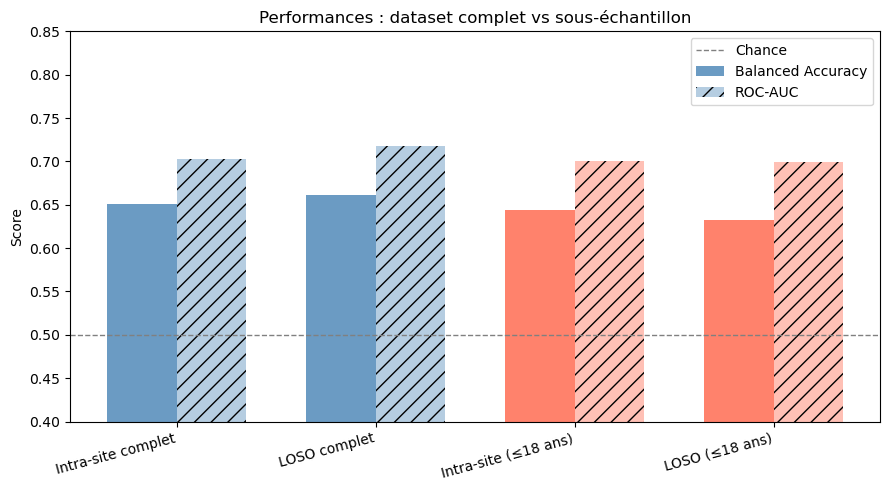

Figure sauvegardée : comparaison_complet_vs_sub.png


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(df_compare))
width = 0.35

bars1 = ax.bar(x - width/2, df_compare["balanced_accuracy"], width,
               color=["steelblue", "steelblue", "tomato", "tomato"],
               alpha=0.8, label="Balanced Accuracy")
bars2 = ax.bar(x + width/2, df_compare["roc_auc"], width,
               color=["steelblue", "steelblue", "tomato", "tomato"],
               alpha=0.4, label="ROC-AUC", hatch="//")

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance")
ax.set_xticks(x)
ax.set_xticklabels(df_compare.index, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0.4, 0.85)
ax.set_title("Performances : dataset complet vs sous-échantillon")
ax.legend()

plt.tight_layout()
plt.savefig("comparaison_complet_vs_sub.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : comparaison_complet_vs_sub.png")

## 10. Discussion

### Résumé des résultats

| Stratégie | Balanced Accuracy | ROC-AUC |
|---|---|---|
| Intra-site — complet | 0.651 | 0.703 |
| LOSO — complet | 0.661 | 0.718 |
| Intra-site — sous-échantillon | 0.644| 0.701 |
| LOSO — sous-échantillon | 0.633 | 0.699 |

### Caractéristiques du sous-échantillon

Le filtre à 18 ans retient 613 participants sur 871 (70% du dataset), répartis en 286 ASD et 327 TD sur 18 sites. Les groupes ASD et TD sont très bien appariés en âge (médiane ~13 ans pour les deux groupes, écart-type ~2.8 ans), ce qui est une propriété favorable pour la classification. Le score ADOS_TOTAL des participants ASD est disponible pour 201 des 286 sujets, avec une médiane de 11.0 et une étendue de 2 à 22, reflétant une hétérogénéité clinique modérée. Deux sites posent problème dans ce sous-échantillon : CALTECH n'a plus qu'un seul participant après le filtre (ignoré), et LEUVEN_1 n'a qu'un sujet dans la classe minoritaire (ignoré).

### Impact du sous-échantillonnage sur les performances

Les performances baissent légèrement en se restreignant aux ≤18 ans : la balanced accuracy passe de 0.651 à 0.644 en intra-site, et de 0.661 à 0.633 en LOSO. Cette baisse modeste (~2%) suggère que restreindre l'âge ne simplifie pas la tâche de classification — le TSA chez l'enfant et l'adolescent reste difficile à détecter par la connectivité fonctionnelle seule.
La variabilité inter-site reste présente dans le LOSO sur le sous-échantillon : LEUVEN_1 obtient une balanced accuracy de 1.0 (mais avec seulement 2 sujets en test, ce résultat n'est pas fiable), tandis que MAX_MUN (0.500) et STANFORD (0.519) restent proches du hasard. OHSU s'améliore légèrement par rapport au LOSO complet (0.558 vs 0.442), ce qui suggère que ses participants adultes étaient particulièrement difficiles à classer.

### Limites

Le sous-échantillonnage réduit la taille de certains sites, rendant les estimations LOSO moins stables pour les petits sites. LEUVEN_1 avec 2 sujets en test et CALTECH avec 1 seul sujet ne sont pas interprétables. Par ailleurs, l'appariement en âge entre ASD et TD dans le sous-échantillon (médiane ~13 ans pour les deux groupes) est une propriété positive, mais il faudrait vérifier formellement avec un test statistique (ex. test de Mann-Whitney) que les distributions sont comparables.

### Conclusion

Restreindre l'analyse aux participants de moins de 18 ans produit un sous-échantillon mieux contrôlé en âge, mais n'améliore pas les performances de classification. L'hétérogénéité inter-site reste la principale source de variabilité, confirmant les conclusions de la tâche 1. Ces résultats suggèrent que les effets de site ne sont pas uniquement liés à la composition en âge des cohortes, et que d'autres facteurs (protocole d'acquisition, critères de recrutement) jouent un rôle important.